# Exploratory Data Analysis — `factory_final.csv`

**Dataset**: Processed Singapore factory/industrial property transactions (Jan 2023 – Dec 2025)  
**Target**: `Unit Price ($ psf)`  
**Rows**: 3,782 | **Columns**: 25

---

## Contents
1. Imports & Data Loading
2. Dataset Overview
3. Missing Values & Duplicates
4. Target Variable Analysis
5. Numerical Features Summary
6. Categorical Features Analysis
7. Temporal Analysis
8. Correlations with Target
9. Group-Level Price Analysis
10. Data Quality Flags
11. Macro Features Assessment
12. EDA Summary & Recommendations

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/factory_final.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 3782 rows x 25 columns


,Contract Date,Project Name,Street Name,Type Of Area,Area (sqft),Floor Level,Unit Price ($ psf),Type of Sale,Region,Planning Area,...,Lease_Duration,Remaining_Lease_Years,GDP_YoY_Growth_Rate,CPI_All_Items,Unemployment_Rate,Price_Index,10Y_Bond_Yield,SORA_3M_Compounded,Cement_Bulk_Per_Tonne,Steel_Rebar_Per_Tonne
0,2025-12-30,PREMIER @ KAKI BUKIT,KAKI BUKIT AVENUE 4,Strata,1098.0,Non-First Floor,619.0,Resale,East Region,Bedok,...,60.0,45.0,4.4,101.588,1.8,111.8,2.22,1.1857,115.9,660.3
1,2025-12-30,FOCUS ONE,UBI VIEW,Strata,5371.0,Non-First Floor,465.0,Resale,Central Region,Geylang,...,60.0,33.0,4.4,101.588,1.8,111.8,2.22,1.1857,115.9,660.3
2,2025-12-30,GOURMET EAST KITCHEN,BEDOK NORTH STREET 5,Strata,2885.0,Non-First Floor,222.0,Resale,East Region,Tampines,...,30.0,6.3,4.4,101.588,1.8,111.8,2.22,1.1857,115.9,660.3
3,2025-12-30,T-SPACE,TAMPINES NORTH DRIVE 1,Strata,1636.0,Non-First Floor,477.0,Resale,East Region,Tampines,...,30.0,19.2,4.4,101.588,1.8,111.8,2.22,1.1857,115.9,660.3
4,2025-12-30,FRONTIER,UBI AVENUE 3,Strata,2207.0,Non-First Floor,453.0,Resale,Central Region,Geylang,...,60.0,33.0,4.4,101.588,1.8,111.8,2.22,1.1857,115.9,660.3


## 2. Dataset Overview

In [2]:
# Column names, types, and non-null counts
print(f"{'Column':<30} {'Dtype':<12} {'Non-Null':>10}")
print("-" * 55)
for col in df.columns:
    print(f"{col:<30} {str(df[col].dtype):<12} {df[col].notna().sum():>10}")

Column                         Dtype          Non-Null
-------------------------------------------------------
Contract Date                  str                3782
Project Name                   str                3757
Street Name                    str                3782
Type Of Area                   str                3782
Area (sqft)                    float64            3782
Floor Level                    str                3782
Unit Price ($ psf)             float64            3782
Type of Sale                   str                3782
Region                         str                3782
Planning Area                  str                3782
Postal District                float64            3782
Postal Sector                  float64            3782
Year                           int64              3782
Month                          int64              3782
Quarter                        int64              3782
Lease_Duration                 float64            3782
Remaining

## 3. Missing Values & Duplicates

In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Pct (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0]

if missing_df.empty:
    print("No missing values found.")
else:
    print("Columns with missing values:")
    display(missing_df)

# Duplicates
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes} ({dupes/len(df)*100:.2f}%)")

Columns with missing values:


,Count,Pct (%)
Project Name,25,0.66



Duplicate rows: 2 (0.05%)


## 4. Target Variable Analysis — `Unit Price ($ psf)`

=== Target Variable Summary ===
  Mean        : 441.69
  Median      : 435.00
  Std Dev     : 178.48
  Min         : 30.00
  Max         : 1460.00
  Skewness    : 0.82
  Kurtosis    : 1.98

Percentiles:
  P1  : $110.00
  P5  : $192.05
  P25 : $303.25
  P50 : $435.00
  P75 : $558.00
  P95 : $703.90
  P99 : $1043.19


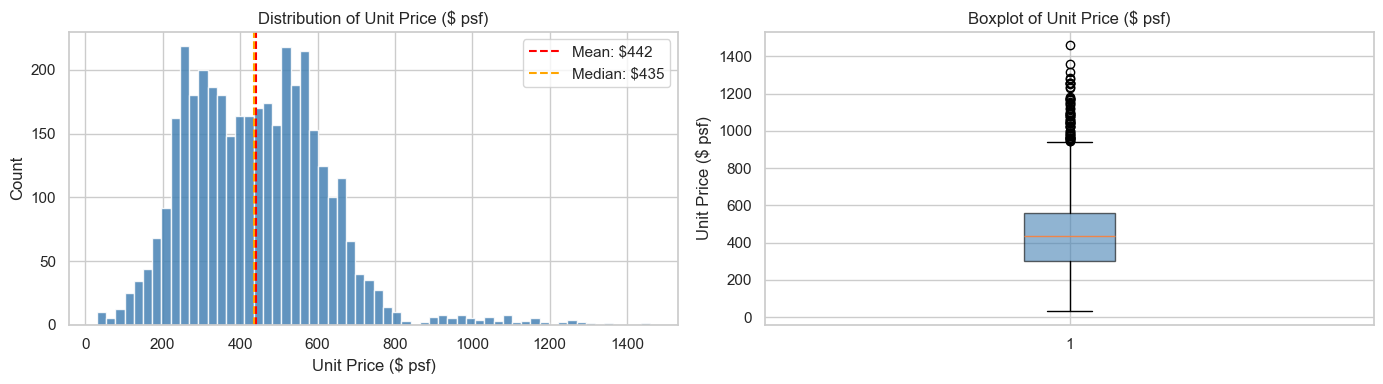

In [4]:
target = df["Unit Price ($ psf)"]

# Summary stats
stats = {
    "Mean": target.mean(), "Median": target.median(), "Std Dev": target.std(),
    "Min": target.min(), "Max": target.max(),
    "Skewness": target.skew(), "Kurtosis": target.kurtosis()
}
print("=== Target Variable Summary ===")
for k, v in stats.items():
    print(f"  {k:<12}: {v:.2f}")

print("\nPercentiles:")
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f"  P{p:<3}: ${target.quantile(p/100):.2f}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(target, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(target.mean(), color="red", linestyle="--", label=f"Mean: ${target.mean():.0f}")
axes[0].axvline(target.median(), color="orange", linestyle="--", label=f"Median: ${target.median():.0f}")
axes[0].set_title("Distribution of Unit Price ($ psf)")
axes[0].set_xlabel("Unit Price ($ psf)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(target, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot of Unit Price ($ psf)")
axes[1].set_ylabel("Unit Price ($ psf)")

plt.tight_layout()
plt.show()

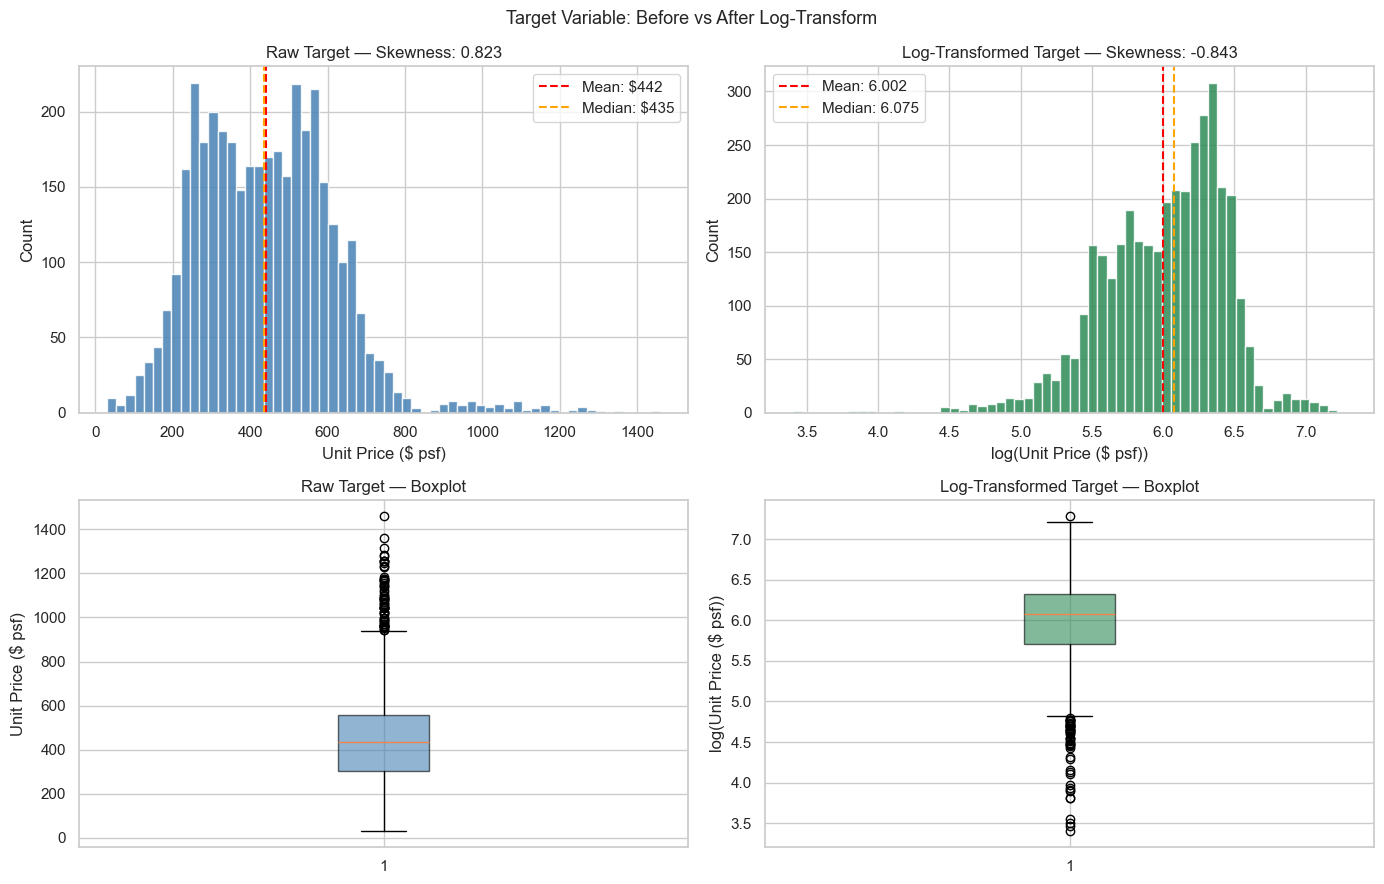

Raw target     — Skewness: 0.823  | Kurtosis: 1.983
Log target     — Skewness: -0.843  | Kurtosis: 2.056

Raw target     — Mean: $441.69  | Std: $178.48
Log target     — Mean: 6.0024  | Std: 0.4424


In [5]:
# Before vs After Log-Transform of Target
log_target = np.log(target)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- Raw distribution ---
axes[0, 0].hist(target, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0, 0].axvline(target.mean(), color="red", linestyle="--", label=f"Mean: ${target.mean():.0f}")
axes[0, 0].axvline(target.median(), color="orange", linestyle="--", label=f"Median: ${target.median():.0f}")
axes[0, 0].set_title(f"Raw Target — Skewness: {target.skew():.3f}")
axes[0, 0].set_xlabel("Unit Price ($ psf)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# --- Log-transformed distribution ---
axes[0, 1].hist(log_target, bins=60, color="seagreen", edgecolor="white", alpha=0.85)
axes[0, 1].axvline(log_target.mean(), color="red", linestyle="--", label=f"Mean: {log_target.mean():.3f}")
axes[0, 1].axvline(log_target.median(), color="orange", linestyle="--", label=f"Median: {log_target.median():.3f}")
axes[0, 1].set_title(f"Log-Transformed Target — Skewness: {log_target.skew():.3f}")
axes[0, 1].set_xlabel("log(Unit Price ($ psf))")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

# --- Raw boxplot ---
axes[1, 0].boxplot(target, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1, 0].set_title("Raw Target — Boxplot")
axes[1, 0].set_ylabel("Unit Price ($ psf)")

# --- Log-transformed boxplot ---
axes[1, 1].boxplot(log_target, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="seagreen", alpha=0.6))
axes[1, 1].set_title("Log-Transformed Target — Boxplot")
axes[1, 1].set_ylabel("log(Unit Price ($ psf))")

plt.suptitle("Target Variable: Before vs After Log-Transform", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Raw target     — Skewness: {target.skew():.3f}  | Kurtosis: {target.kurtosis():.3f}")
print(f"Log target     — Skewness: {log_target.skew():.3f}  | Kurtosis: {log_target.kurtosis():.3f}")
print(f"\nRaw target     — Mean: ${target.mean():.2f}  | Std: ${target.std():.2f}")
print(f"Log target     — Mean: {log_target.mean():.4f}  | Std: {log_target.std():.4f}")

## 5. Numerical Features Summary

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().round(2)

,Area (sqft),Unit Price ($ psf),Postal District,Postal Sector,Year,Month,Quarter,Lease_Duration,Remaining_Lease_Years,GDP_YoY_Growth_Rate,CPI_All_Items,Unemployment_Rate,Price_Index,10Y_Bond_Yield,SORA_3M_Compounded,Cement_Bulk_Per_Tonne,Steel_Rebar_Per_Tonne
count,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00,3782.00
mean,2474.11,441.69,19.92,56.62,2024.00,6.54,2.52,52.04,32.86,3.98,99.54,1.96,105.22,2.78,3.05,109.69,788.36
std,2231.05,178.48,5.85,15.95,0.81,3.31,1.09,16.69,11.65,6.74,1.49,0.28,3.75,0.44,0.84,5.24,84.23
min,517.00,30.00,3.00,12.00,2023.00,1.00,1.00,19.00,1.90,-8.60,96.29,1.60,99.40,1.83,1.19,101.10,660.30
25%,1378.00,303.25,14.00,41.00,2023.00,4.00,2.00,30.00,20.20,0.70,98.99,1.80,102.70,2.62,2.55,104.40,701.30
50%,1765.00,435.00,22.00,62.00,2024.00,7.00,3.00,60.00,33.40,4.40,99.91,1.90,103.90,2.86,3.57,110.00,805.70
75%,2605.00,558.00,25.00,73.00,2025.00,9.00,3.00,60.00,43.80,10.20,100.40,2.40,108.10,3.10,3.65,113.50,830.10
max,22314.00,1460.00,27.00,76.00,2025.00,12.00,4.00,99.00,59.90,14.90,101.59,2.40,111.80,3.45,3.75,118.50,946.60


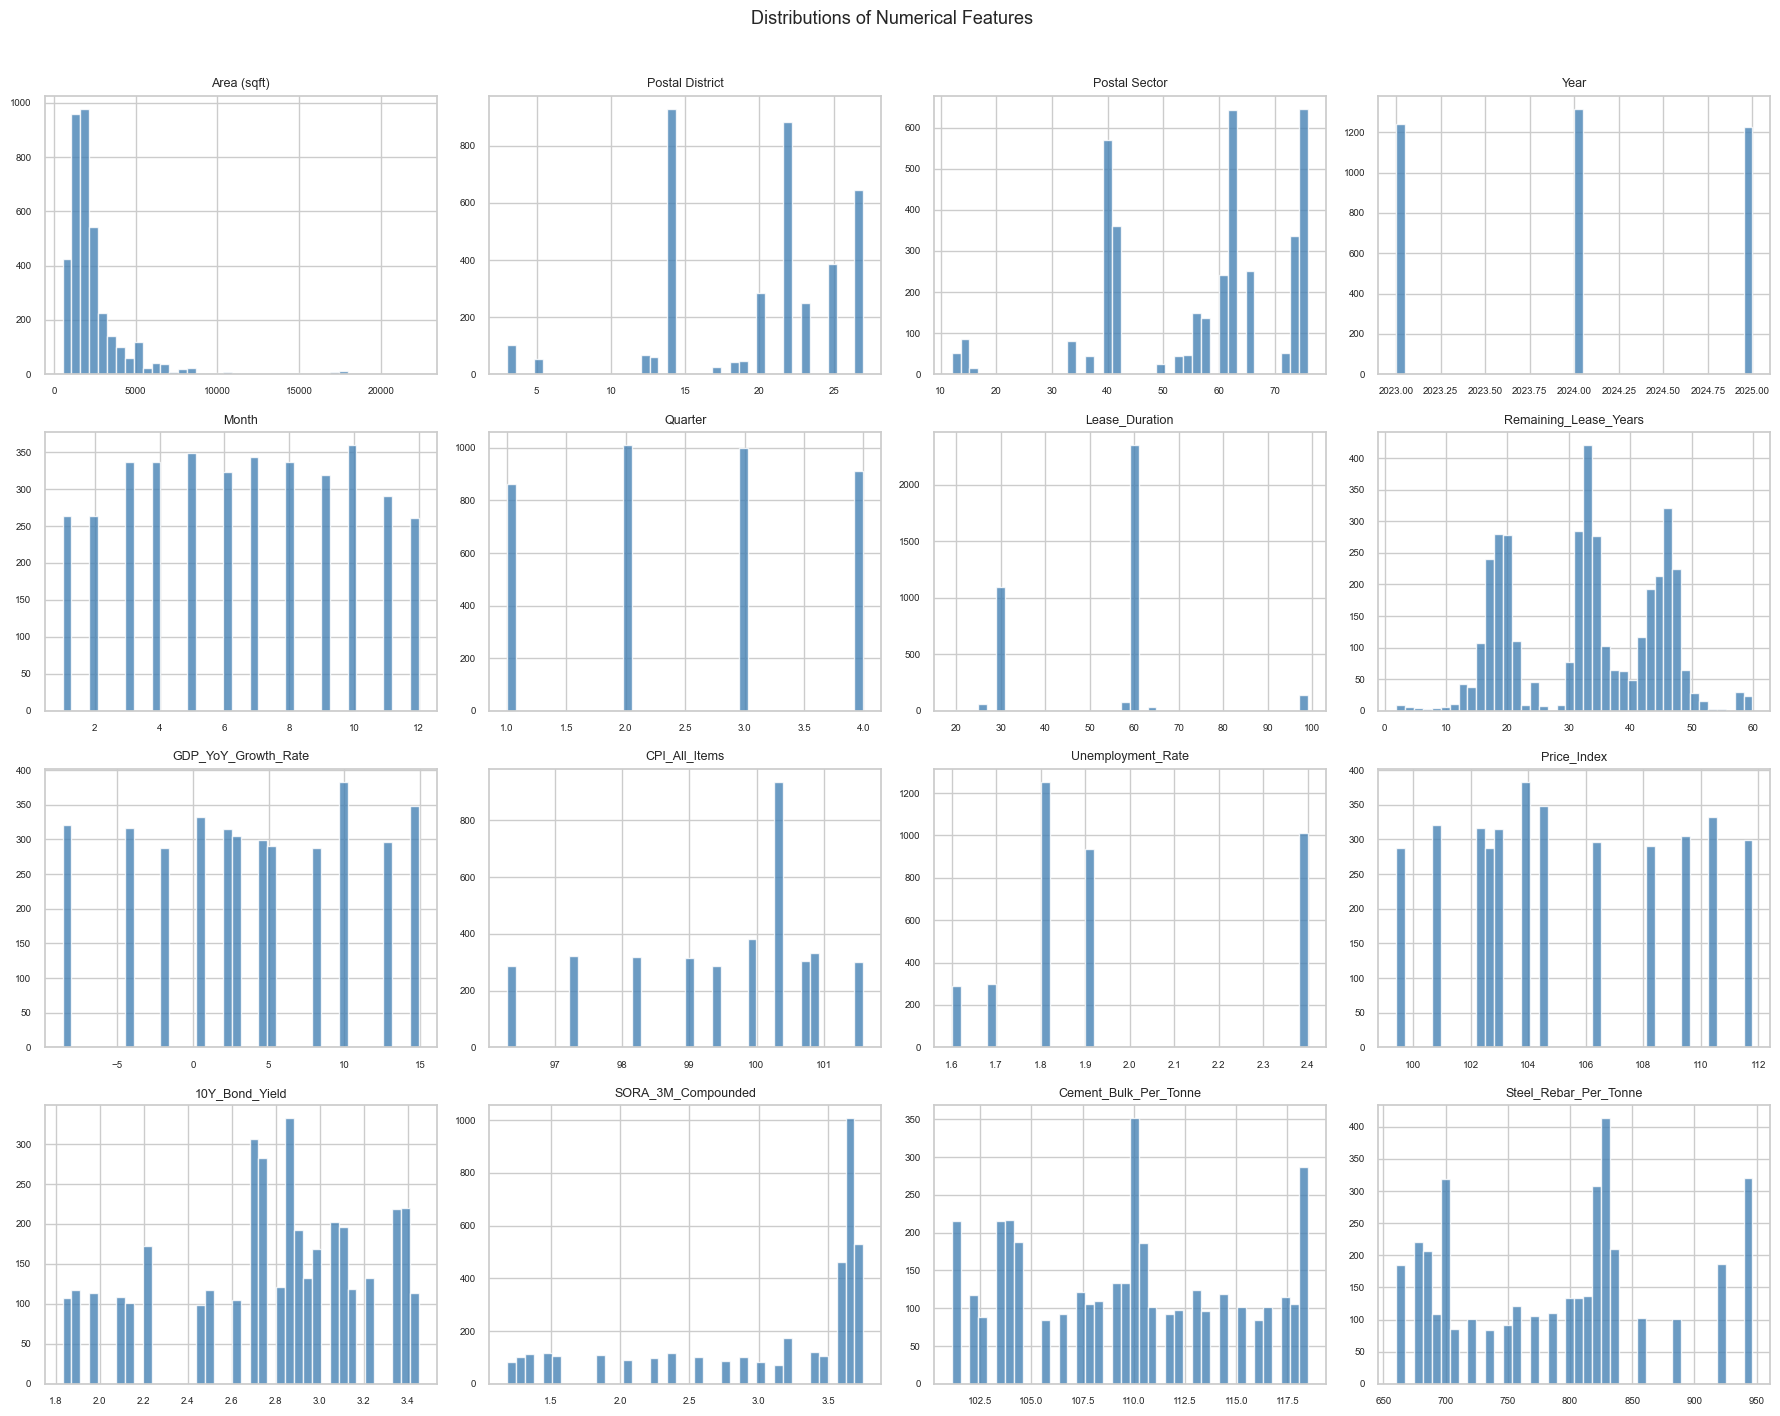

In [7]:
# Distribution plots for all numerical features (excluding target)
feature_cols = [c for c in num_cols if c != "Unit Price ($ psf)"]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=7)

# Hide unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Numerical Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Categorical Features Analysis

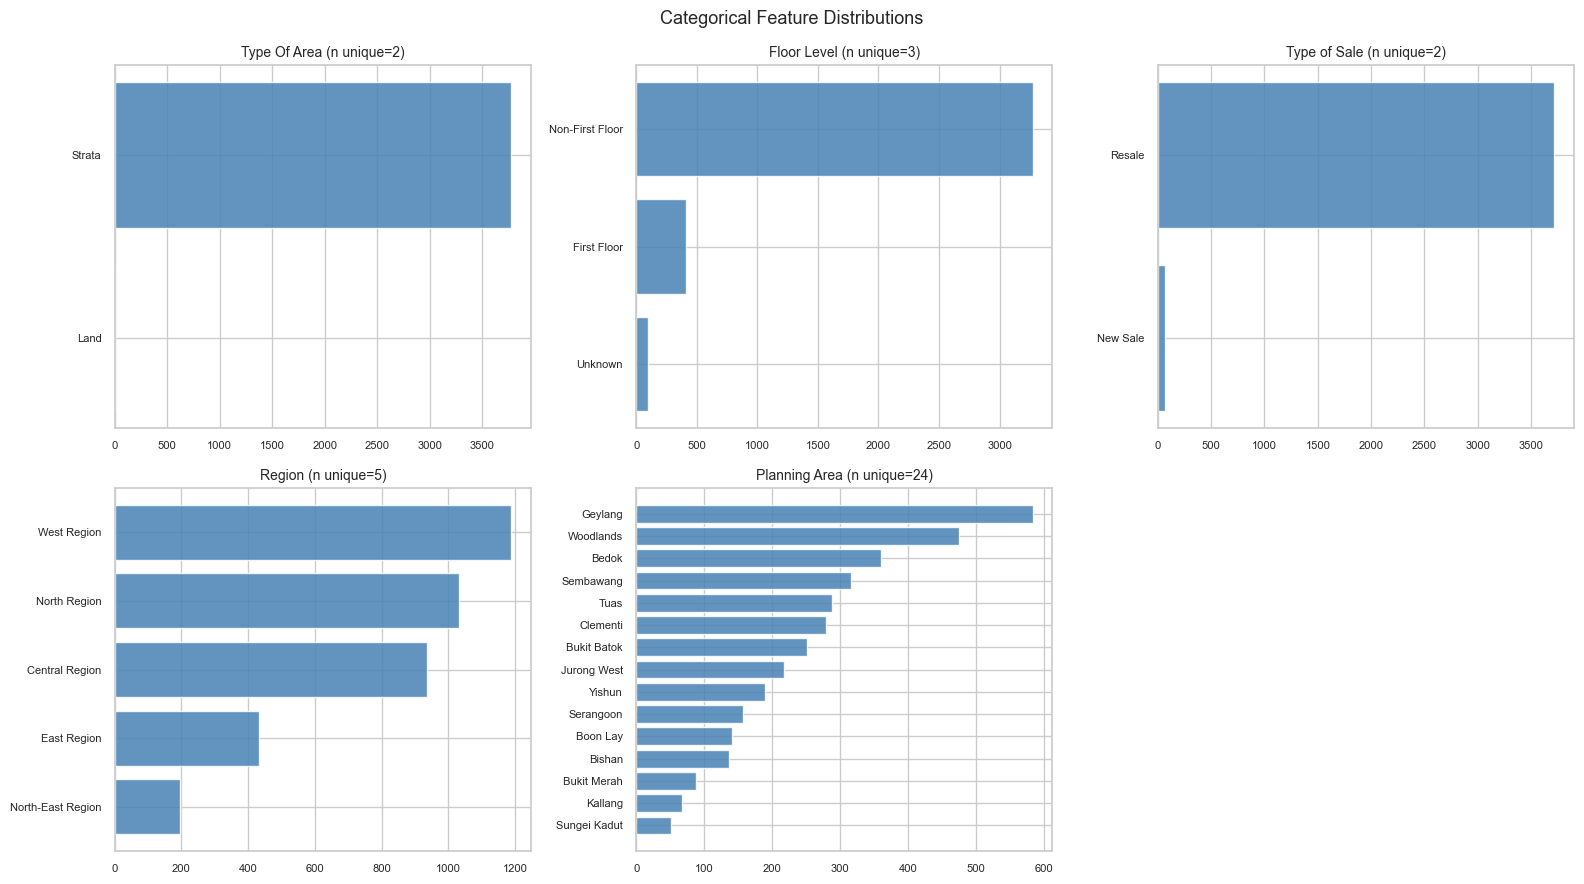


--- Type Of Area ---
Type Of Area
Strata    3775
Land         7

--- Floor Level ---
Floor Level
Non-First Floor    3273
First Floor         414
Unknown              95

--- Type of Sale ---
Type of Sale
Resale      3716
New Sale      66

--- Region ---
Region
West Region          1188
North Region         1032
Central Region        935
East Region           432
North-East Region     195

--- Planning Area ---
Planning Area
Geylang         583
Woodlands       475
Bedok           360
Sembawang       316
Tuas            288
Clementi        279
Bukit Batok     251
Jurong West     218
Yishun          190
Serangoon       157
Boon Lay        141
Bishan          137
Bukit Merah      88
Kallang          68
Sungei Kadut     51
Tampines         45
Toa Payoh        45
Ang Mo Kio       38
Pasir Ris        20
Queenstown       14
Pioneer           7
Changi            6
Jurong East       4
Paya Lebar        1


In [8]:
cat_cols = ["Type Of Area", "Floor Level", "Type of Sale", "Region", "Planning Area"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    axes[i].barh(vc.index[:15], vc.values[:15], color="steelblue", alpha=0.85)
    axes[i].set_title(f"{col} (n unique={df[col].nunique()})", fontsize=10)
    axes[i].tick_params(labelsize=8)
    axes[i].invert_yaxis()

axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

# Print value counts
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().to_string())

## 7. Temporal Analysis

Date range: 2023-01-03 to 2025-12-30

Year distribution:
Year
2023    1240
2024    1315
2025    1227


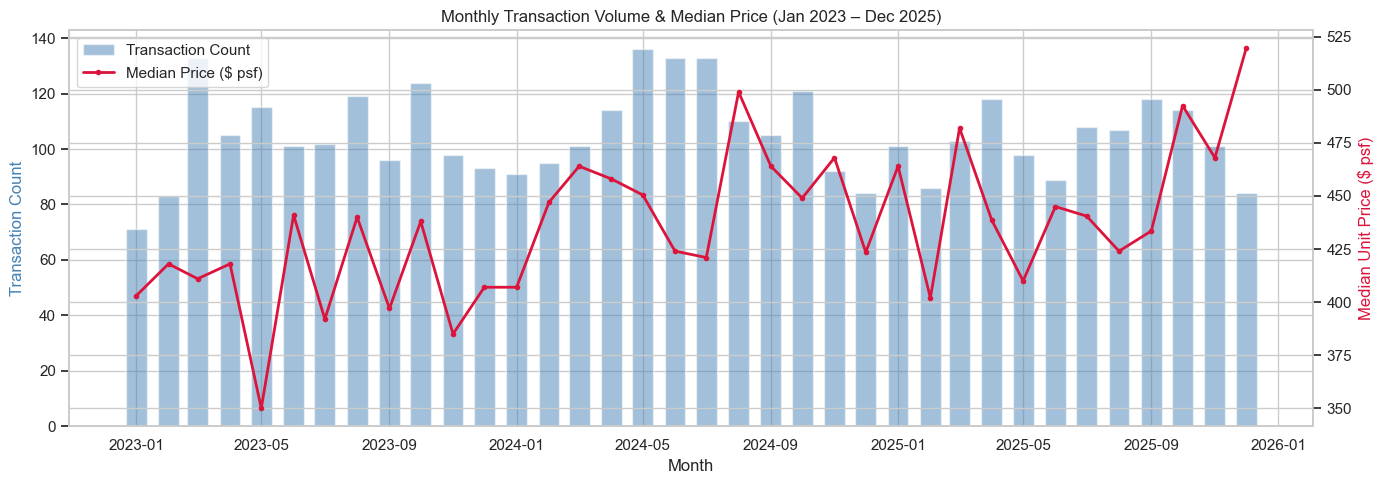


Lease Duration distribution:
Lease_Duration
19.0       5
20.0       2
26.0      64
30.0    1098
41.0       6
45.0       2
57.0      54
58.0      24
60.0    2347
63.0      38
99.0     142


In [9]:
print(f"Date range: {df['Contract Date'].min()} to {df['Contract Date'].max()}")
print(f"\nYear distribution:")
print(df["Year"].value_counts().sort_index().to_string())

# Monthly transaction volume and median price over time
df["Contract Date"] = pd.to_datetime(df["Contract Date"])
monthly = df.groupby(df["Contract Date"].dt.to_period("M")).agg(
    transactions=("Unit Price ($ psf)", "count"),
    median_price=("Unit Price ($ psf)", "median")
).reset_index()
monthly["Contract Date"] = monthly["Contract Date"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly["Contract Date"], monthly["transactions"], width=20,
        color="steelblue", alpha=0.5, label="Transaction Count")
ax2.plot(monthly["Contract Date"], monthly["median_price"],
         color="crimson", linewidth=2, marker="o", markersize=3, label="Median Price ($ psf)")

ax1.set_xlabel("Month")
ax1.set_ylabel("Transaction Count", color="steelblue")
ax2.set_ylabel("Median Unit Price ($ psf)", color="crimson")
ax1.set_title("Monthly Transaction Volume & Median Price (Jan 2023 – Dec 2025)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

print("\nLease Duration distribution:")
print(df["Lease_Duration"].value_counts().sort_index().to_string())

## 8. Correlations with Target

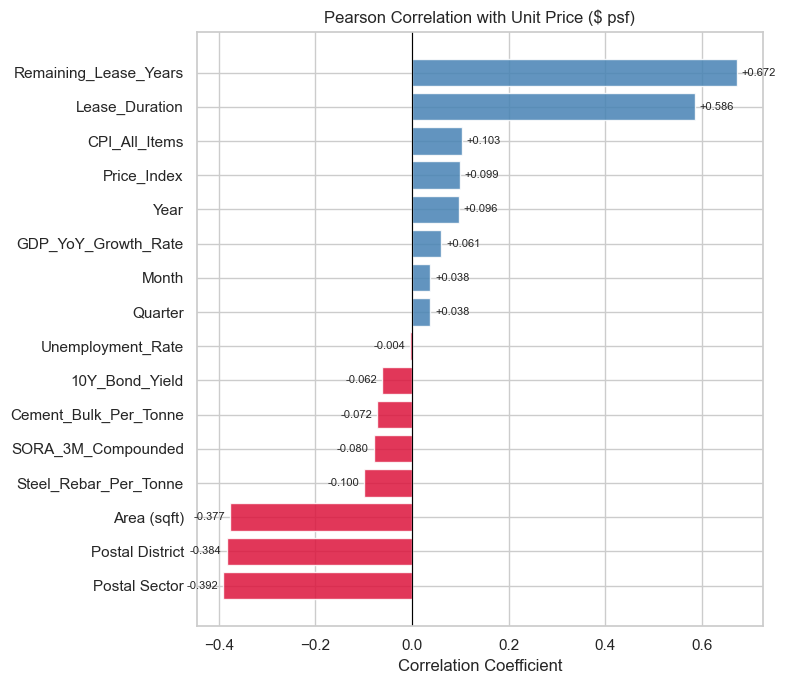


Correlation with target (sorted):
  +0.672  Remaining_Lease_Years *** HIGH ***
  +0.586  Lease_Duration *** HIGH ***
  +0.103  CPI_All_Items
  +0.099  Price_Index
  +0.096  Year
  +0.061  GDP_YoY_Growth_Rate
  +0.038  Month
  +0.038  Quarter
  -0.004  Unemployment_Rate
  -0.062  10Y_Bond_Yield
  -0.072  Cement_Bulk_Per_Tonne
  -0.080  SORA_3M_Compounded
  -0.100  Steel_Rebar_Per_Tonne
  -0.377  Area (sqft) ** MOD **
  -0.384  Postal District ** MOD **
  -0.392  Postal Sector ** MOD **


In [10]:
corr_target = df[num_cols].corr()["Unit Price ($ psf)"].drop("Unit Price ($ psf)").sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["crimson" if v < 0 else "steelblue" for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation with Unit Price ($ psf)")
ax.set_xlabel("Correlation Coefficient")

for bar, val in zip(bars, corr_target.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
plt.show()

print("\nCorrelation with target (sorted):")
for feat, val in corr_target.sort_values(ascending=False).items():
    flag = " *** HIGH ***" if abs(val) > 0.5 else (" ** MOD **" if abs(val) > 0.3 else "")
    print(f"  {val:+.3f}  {feat}{flag}")

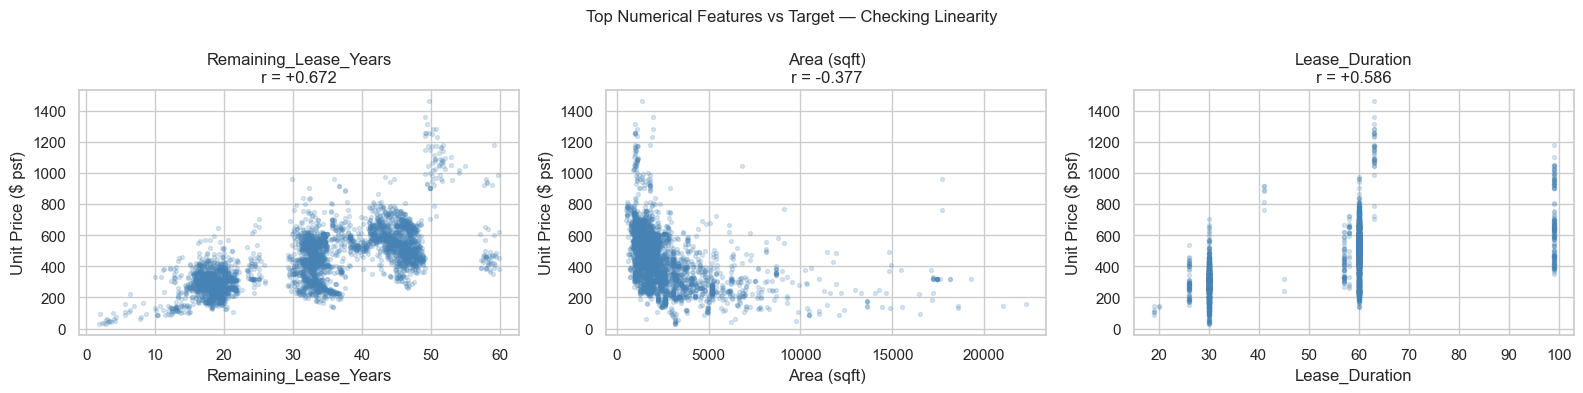

NOTE: Area (sqft) shows a curved relationship with target — bulk discount effect
      diminishes non-linearly as size increases. Log-transform recommended.
      Area skewness: 3.947


In [11]:
# Scatter plots — Top features vs target (to check linearity)
# Area (sqft) is included to show curved relationship — motivates log-transform in feature engineering

top_features = ["Remaining_Lease_Years", "Area (sqft)", "Lease_Duration"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df["Unit Price ($ psf)"], alpha=0.2, s=8, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Unit Price ($ psf)")
    r = df[col].corr(df["Unit Price ($ psf)"])
    axes[i].set_title(f"{col}\nr = {r:+.3f}")

plt.suptitle("Top Numerical Features vs Target — Checking Linearity", fontsize=12)
plt.tight_layout()
plt.show()

print("NOTE: Area (sqft) shows a curved relationship with target — bulk discount effect")
print("      diminishes non-linearly as size increases. Log-transform recommended.")
print(f"      Area skewness: {df['Area (sqft)'].skew():.3f}")

## 9. Group-Level Price Analysis

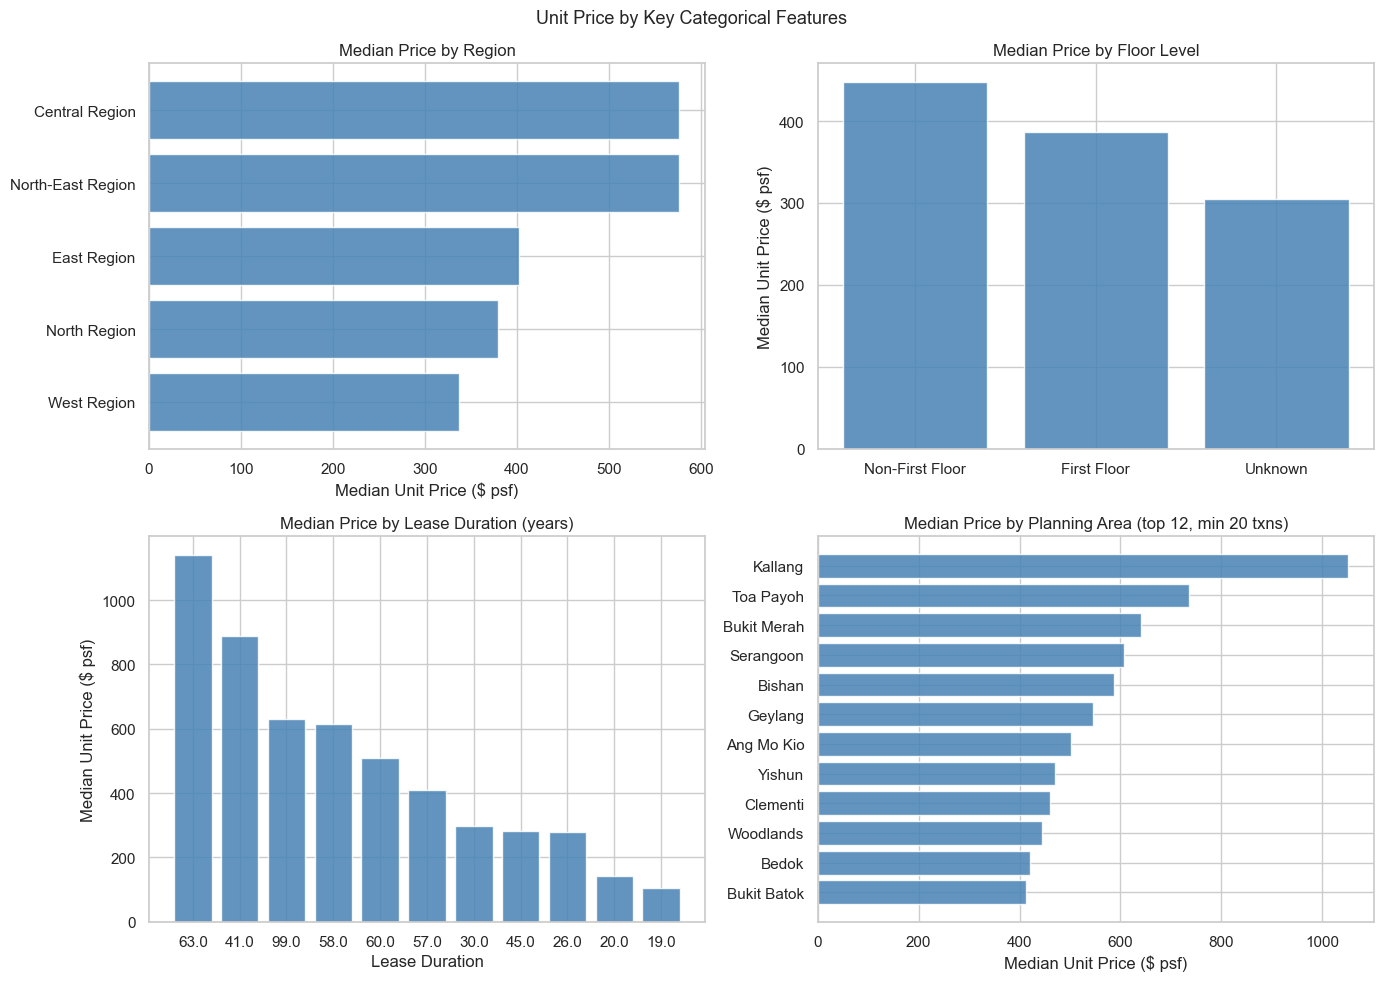

Median Price by Type of Sale:
               mean  median  count
Type of Sale                      
New Sale      576.1   588.0     66
Resale        439.3   430.0   3716


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Region
region_stats = df.groupby("Region")["Unit Price ($ psf)"].median().sort_values(ascending=False)
axes[0, 0].barh(region_stats.index, region_stats.values, color="steelblue", alpha=0.85)
axes[0, 0].set_title("Median Price by Region")
axes[0, 0].set_xlabel("Median Unit Price ($ psf)")
axes[0, 0].invert_yaxis()

# Floor Level
fl_stats = df.groupby("Floor Level")["Unit Price ($ psf)"].median().sort_values(ascending=False)
axes[0, 1].bar(fl_stats.index, fl_stats.values, color="steelblue", alpha=0.85)
axes[0, 1].set_title("Median Price by Floor Level")
axes[0, 1].set_ylabel("Median Unit Price ($ psf)")

# Lease Duration
lease_stats = df.groupby("Lease_Duration")["Unit Price ($ psf)"].median().sort_values(ascending=False)
axes[1, 0].bar(lease_stats.index.astype(str), lease_stats.values, color="steelblue", alpha=0.85)
axes[1, 0].set_title("Median Price by Lease Duration (years)")
axes[1, 0].set_xlabel("Lease Duration")
axes[1, 0].set_ylabel("Median Unit Price ($ psf)")

# Top planning areas (min 20 transactions)
pa_stats = df.groupby("Planning Area")["Unit Price ($ psf)"].agg(["median", "count"])
pa_stats = pa_stats[pa_stats["count"] >= 20].sort_values("median", ascending=False).head(12)
axes[1, 1].barh(pa_stats.index, pa_stats["median"], color="steelblue", alpha=0.85)
axes[1, 1].set_title("Median Price by Planning Area (top 12, min 20 txns)")
axes[1, 1].set_xlabel("Median Unit Price ($ psf)")
axes[1, 1].invert_yaxis()

plt.suptitle("Unit Price by Key Categorical Features", fontsize=13)
plt.tight_layout()
plt.show()

# Type of Sale
print("Median Price by Type of Sale:")
print(df.groupby("Type of Sale")["Unit Price ($ psf)"].agg(["mean","median","count"]).round(1).to_string())

## 10. Data Quality Flags

In [13]:
# IQR-based outliers on target
q1 = target.quantile(0.25)
q3 = target.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(target < lower) | (target > upper)]

issues = {
    "Duplicate rows": df.duplicated().sum(),
    f"Target outliers (IQR [{lower:.0f}, {upper:.0f}])": len(outliers),
    "Missing Project Name": df["Project Name"].isna().sum(),
    "Type Of Area = Land (rare class)": (df["Type Of Area"] == "Land").sum(),
    "Floor Level = Unknown": (df["Floor Level"] == "Unknown").sum(),
    "Type of Sale = New Sale (rare class)": (df["Type of Sale"] == "New Sale").sum(),
    "Remaining Lease < 5 years": (df["Remaining_Lease_Years"] < 5).sum(),
    "Area > 10,000 sqft (large units)": (df["Area (sqft)"] > 10000).sum(),
}

print(f"{'Issue':<55} {'Count':>6}  {'% of Total':>10}")
print("-" * 75)
for desc, count in issues.items():
    pct = count / len(df) * 100
    print(f"{desc:<55} {count:>6}  {pct:>9.2f}%")

Issue                                                    Count  % of Total
---------------------------------------------------------------------------
Duplicate rows                                               2       0.05%
Target outliers (IQR [-79, 940])                            61       1.61%
Missing Project Name                                        25       0.66%
Type Of Area = Land (rare class)                             7       0.19%
Floor Level = Unknown                                       95       2.51%
Type of Sale = New Sale (rare class)                        66       1.75%
Remaining Lease < 5 years                                   15       0.40%
Area > 10,000 sqft (large units)                            67       1.77%


## 11. Macro Features Assessment

Macro features — unique value counts (all transactions share quarterly values):
  GDP_YoY_Growth_Rate           :  12 unique values
  CPI_All_Items                 :  12 unique values
  Unemployment_Rate             :   5 unique values
  Price_Index                   :  12 unique values
  10Y_Bond_Yield                :  33 unique values
  SORA_3M_Compounded            :  36 unique values
  Cement_Bulk_Per_Tonne         :  34 unique values
  Steel_Rebar_Per_Tonne         :  36 unique values


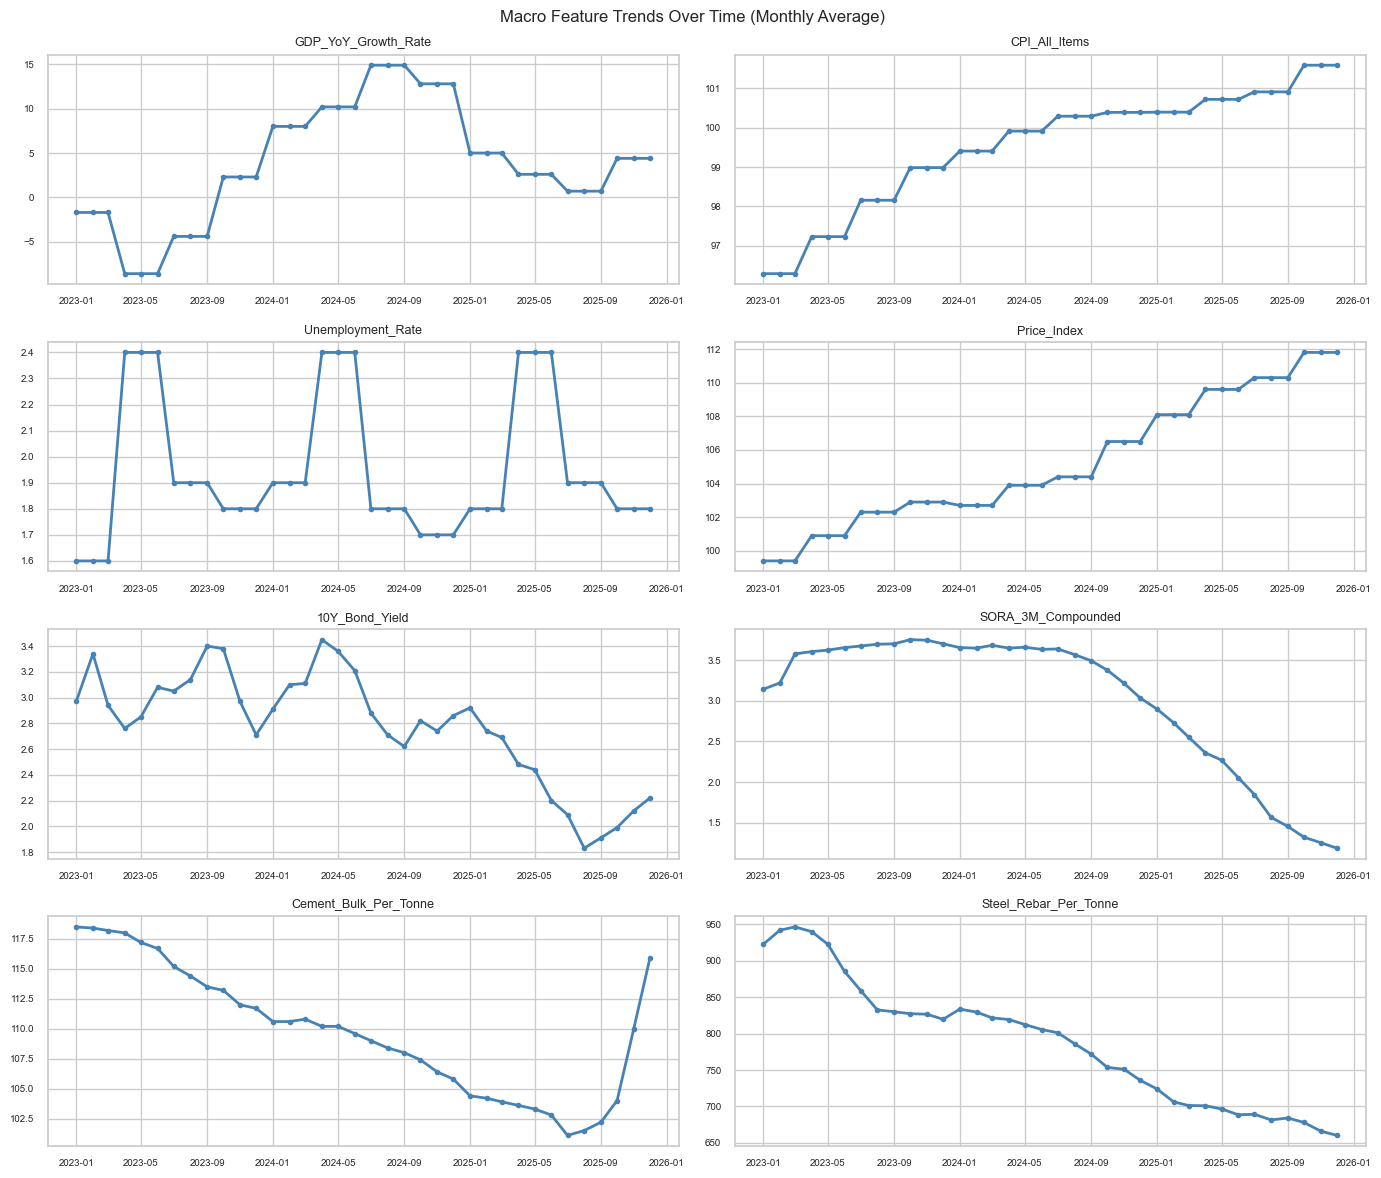

In [14]:
macro_cols = ["GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
              "Price_Index", "10Y_Bond_Yield", "SORA_3M_Compounded",
              "Cement_Bulk_Per_Tonne", "Steel_Rebar_Per_Tonne"]

print("Macro features — unique value counts (all transactions share quarterly values):")
for col in macro_cols:
    print(f"  {col:<30}: {df[col].nunique():>3} unique values")

# Macro feature trends over time
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

monthly_macro = df.groupby(df["Contract Date"].dt.to_period("M"))[macro_cols].mean().reset_index()
monthly_macro["Contract Date"] = monthly_macro["Contract Date"].dt.to_timestamp()

for i, col in enumerate(macro_cols):
    axes[i].plot(monthly_macro["Contract Date"], monthly_macro[col],
                 color="steelblue", linewidth=2, marker="o", markersize=3)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle("Macro Feature Trends Over Time (Monthly Average)", fontsize=12)
plt.tight_layout()
plt.show()

## 12. EDA Summary & Recommendations

### Key Findings

| # | Finding | Action |
|---|---------|--------|
| 1 | `Remaining_Lease_Years` (r=+0.672) and `Lease_Duration` (r=+0.586) are the strongest predictors | Prioritise in feature selection; check collinearity between them |
| 2 | `Postal_Sector` (r=-0.392) and `Postal_District` (r=-0.384) appear as moderate predictors | **Drop both** — they are numerical codes (identifiers), not true continuous variables. The correlation is a coincidence of Singapore's postal numbering. Location is better captured by `Region` and `Planning Area` |
| 3 | `Area (sqft)` (r=-0.377) is a moderate predictor | Keep — reflects genuine bulk discount effect. Consider log-transform |
| 4 | `Unemployment_Rate` (r=-0.004) has near-zero correlation with target | Drop — near-constant (only 5 unique values), no meaningful signal |
| 5 | Target is right-skewed (skew=0.82) | Consider log-transform for linear models |
| 6 | 2 duplicate rows | Drop before modelling |
| 7 | `Type Of Area = Land` (7 rows, 0.19%) | Drop — too few to learn from |
| 8 | `Type of Sale = New Sale` (66 rows, 1.7%) | Consider merging with Resale or dropping |
| 9 | `Floor Level = Unknown` (95 rows) | Treat as a separate category |
| 10 | 8 macro features are quarterly aggregates (5–36 unique values) | High multicollinearity risk — investigate in next notebook |
| 11 | `Year`, `Month`, `Quarter` are mapping keys used to join macro data | Exclude from model features entirely |

### Next Step
→ `notebooks/03_multicollinearity_analysis.ipynb` — VIF analysis and feature selection